In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from skimage import data
import warnings
warnings.filterwarnings('ignore')

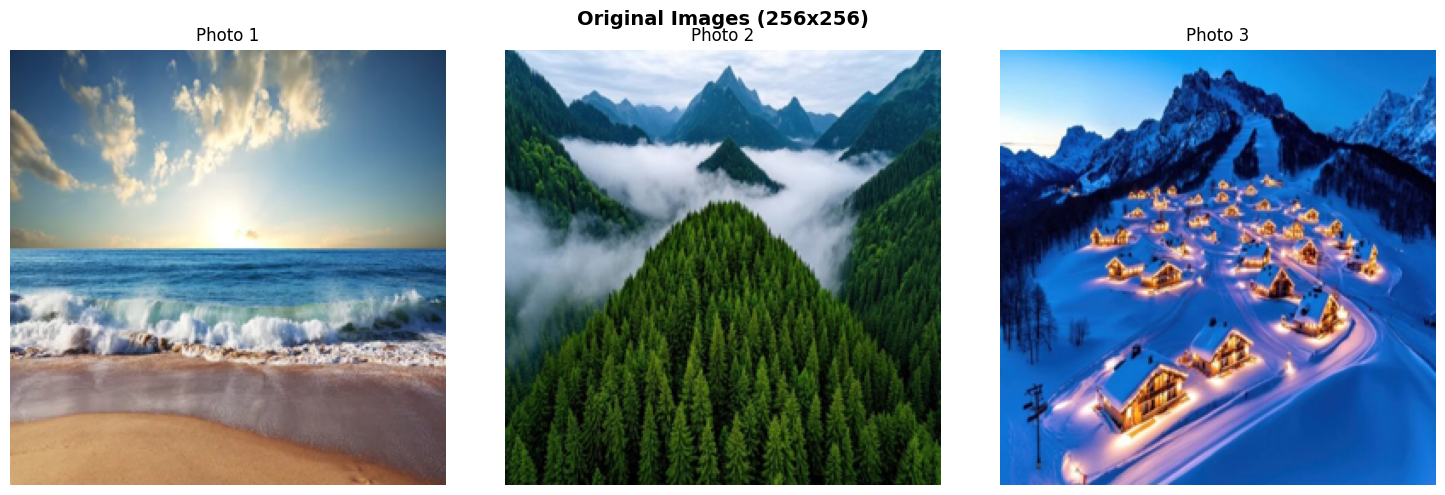

In [11]:
img1 = np.array(Image.open("stockphoto1.jpg").resize((256, 256)))
img2 = np.array(Image.open("stockphoto2.jpg").resize((256, 256)))
img3 = np.array(Image.open("stockphoto3.jpg").resize((256, 256)))

images = {
    "Photo 1": img1,
    "Photo 2": img2,
    "Photo 3": img3,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Original Images (256x256)", fontsize=14, fontweight='bold')
for ax, (name, img) in zip(axes, images.items()):
    ax.imshow(img)
    ax.set_title(name)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [12]:
def downsample_max(img, factor=4):
    h, w = img.shape[:2]
    nh, nw = h // factor, w // factor
    out = np.zeros((nh, nw, img.shape[2]), dtype=img.dtype)
    for c in range(img.shape[2]):
        blocks = img[:nh*factor, :nw*factor, c].reshape(nh, factor, nw, factor)
        out[..., c] = blocks.max(axis=(1, 3))
    return out

def downsample_average(img, factor=4):
    h, w = img.shape[:2]
    nh, nw = h // factor, w // factor
    out = np.zeros((nh, nw, img.shape[2]), dtype=np.uint8)
    for c in range(img.shape[2]):
        blocks = img[:nh*factor, :nw*factor, c].reshape(nh, factor, nw, factor)
        out[..., c] = blocks.mean(axis=(1, 3)).astype(np.uint8)
    return out

def downsample_median(img, factor=4):
    h, w = img.shape[:2]
    nh, nw = h // factor, w // factor
    out = np.zeros((nh, nw, img.shape[2]), dtype=np.uint8)
    for c in range(img.shape[2]):
        blocks = img[:nh*factor, :nw*factor, c].reshape(nh, factor, nw, factor)
        out[..., c] = np.median(blocks, axis=(1, 3)).astype(np.uint8)
    return out

FACTOR = 4
print(f"Downsampling factor: {FACTOR}x  →  256x256 becomes 64x64")

Downsampling factor: 4x  →  256x256 becomes 64x64


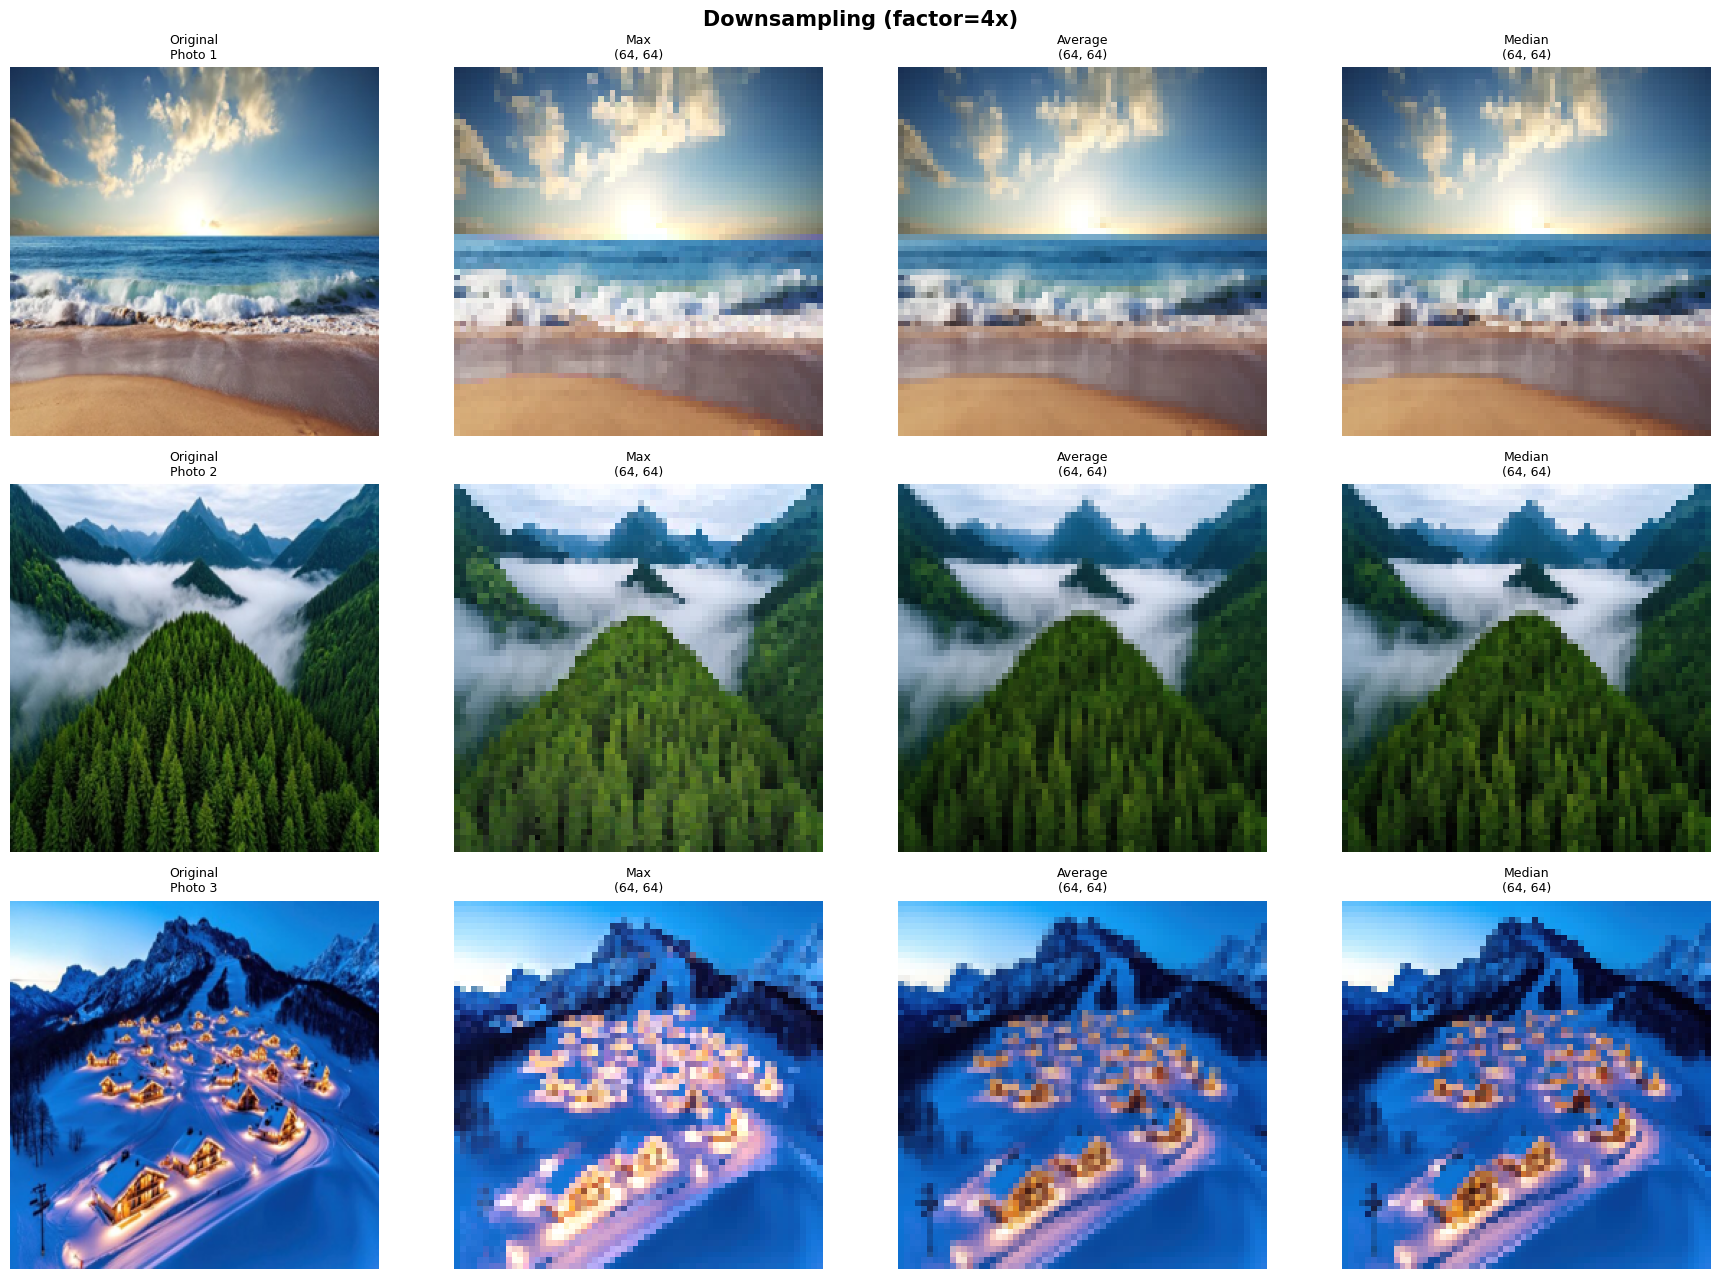

In [13]:
down_methods = {"Max": downsample_max, "Average": downsample_average, "Median": downsample_median}
down_results = {}

fig, axes = plt.subplots(3, 4, figsize=(18, 13))
fig.suptitle(f"Downsampling (factor={FACTOR}x)", fontsize=15, fontweight='bold')

for row, (img_name, img) in enumerate(images.items()):
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"Original\n{img_name}", fontsize=9)
    axes[row, 0].axis('off')
    down_results[img_name] = {}
    for col, (method_name, fn) in enumerate(down_methods.items(), start=1):
        result = fn(img, factor=FACTOR)
        down_results[img_name][method_name] = result
        axes[row, col].imshow(result)
        axes[row, col].set_title(f"{method_name}\n{result.shape[:2]}", fontsize=9)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig("downsampling_results.png", dpi=150, bbox_inches='tight')
plt.show()

In [14]:
def upsample_nn(img, scale=4):
    pil = Image.fromarray(img)
    w, h = pil.size
    return np.array(pil.resize((w * scale, h * scale), Image.NEAREST))

def upsample_bilinear(img, scale=4):
    pil = Image.fromarray(img)
    w, h = pil.size
    return np.array(pil.resize((w * scale, h * scale), Image.BILINEAR))

def upsample_bicubic(img, scale=4):
    pil = Image.fromarray(img)
    w, h = pil.size
    return np.array(pil.resize((w * scale, h * scale), Image.BICUBIC))

up_methods = {
    "Nearest-Neighbour": upsample_nn,
    "Bilinear"         : upsample_bilinear,
    "Bicubic"          : upsample_bicubic,
}

print("Upsampling: 64x64 → 256x256")

Upsampling: 64x64 → 256x256


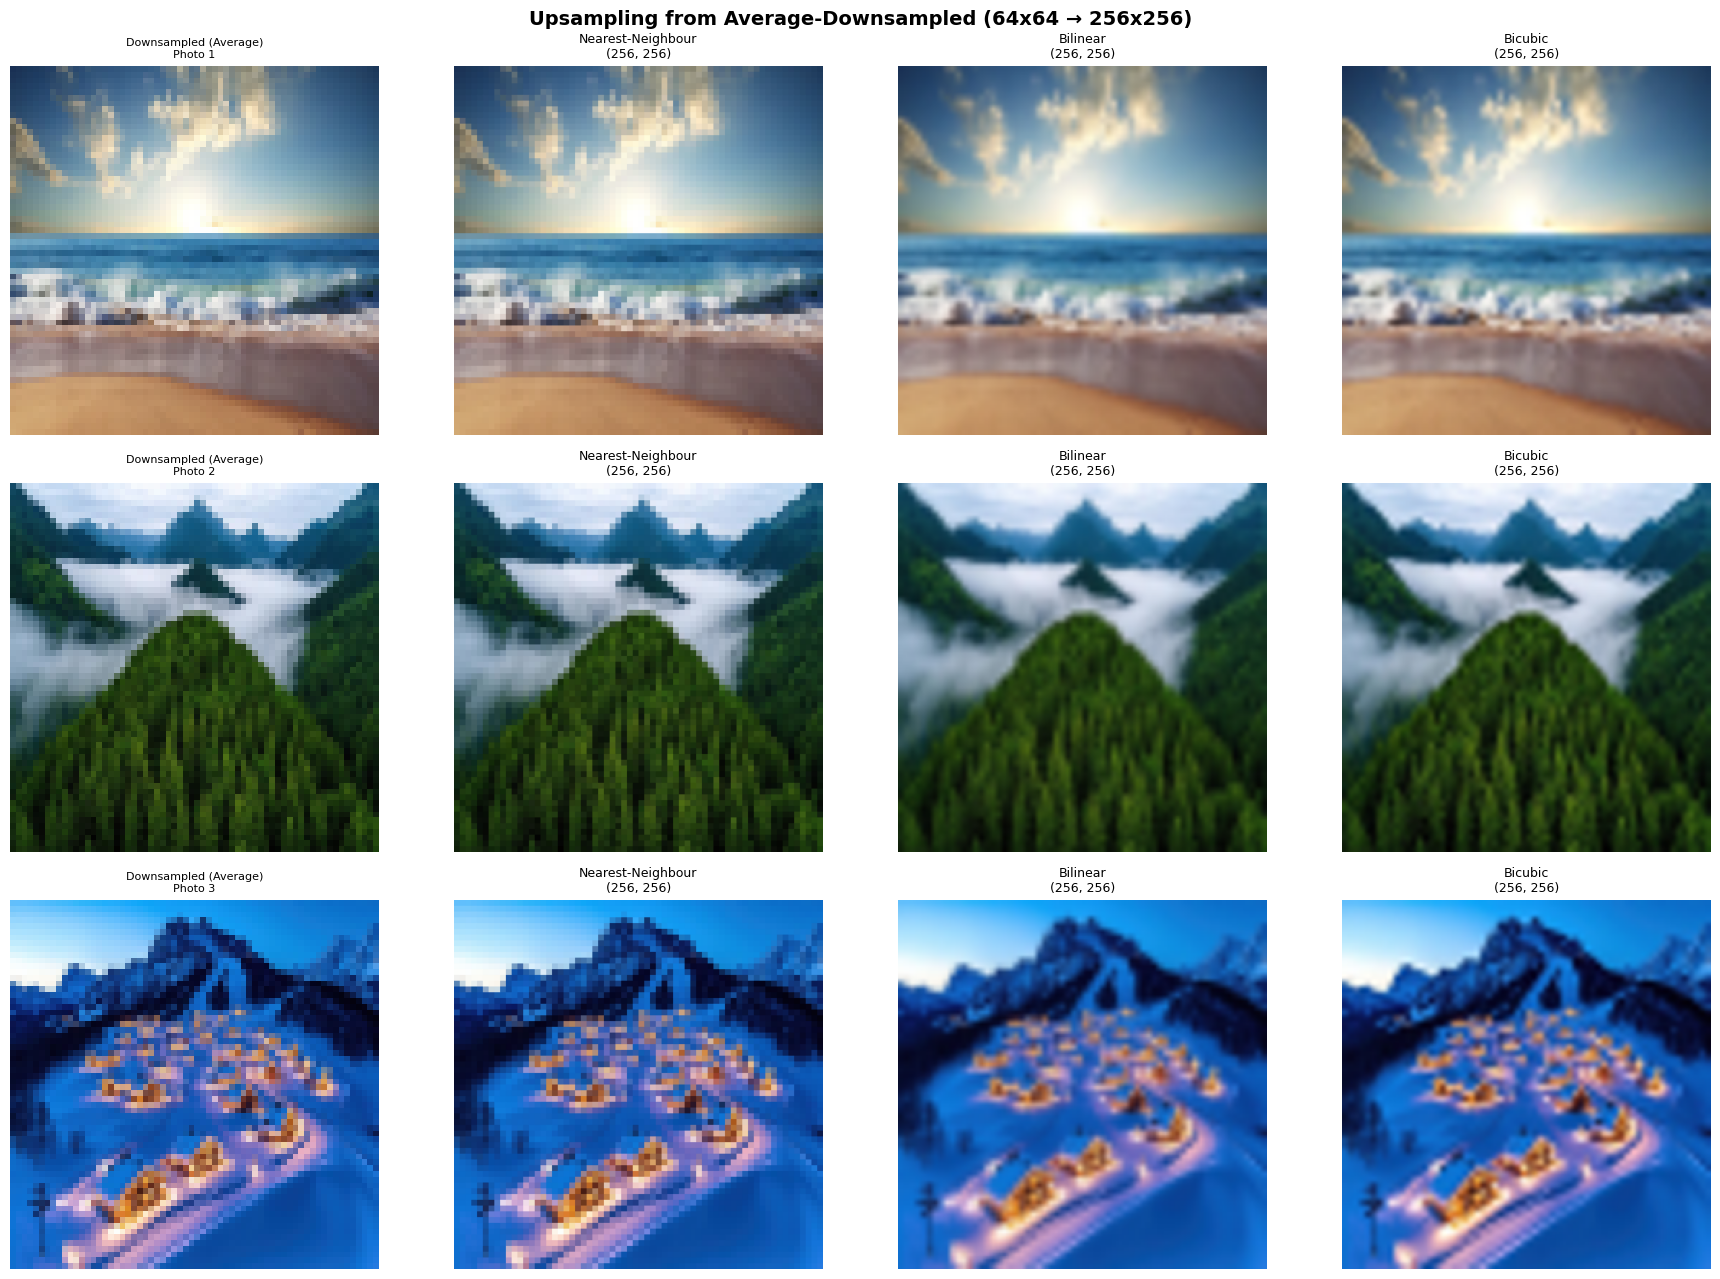

In [16]:
up_results = {}
DOWN_SRC = "Average"

fig, axes = plt.subplots(3, 4, figsize=(18, 13))
fig.suptitle(f"Upsampling from {DOWN_SRC}-Downsampled (64x64 → 256x256)", fontsize=14, fontweight='bold')

for row, img_name in enumerate(images):
    src = down_results[img_name][DOWN_SRC]
    up_results[img_name] = {}
    axes[row, 0].imshow(src)
    axes[row, 0].set_title(f"Downsampled ({DOWN_SRC})\n{img_name}", fontsize=8)
    axes[row, 0].axis('off')
    for col, (method_name, fn) in enumerate(up_methods.items(), start=1):
        result = fn(src, scale=FACTOR)
        up_results[img_name][method_name] = result
        axes[row, col].imshow(result)
        axes[row, col].set_title(f"{method_name}\n{result.shape[:2]}", fontsize=9)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig("upsampling_results.png", dpi=150, bbox_inches='tight')
plt.show()